In [9]:
import pandas as pd
from SynFileUtils import SynFileReader
import re

In [10]:
mirna_path = '/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirFormTM/results/mirna_relaxed.hits'
taxon_path = '/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/taxon_hits_20260603_191129/taxon_hits_20260603_191129.hits'
family_path = '/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirna_families.tsv'

#mirna_hits = pd.read_csv(mirna_path, sep='\t', quoting=3)
taxon_hits = pd.read_csv(taxon_path, sep ='\t', quoting=3)
#mirna_families = pd.read_csv(family_path, sep='\t')
#mirna_families.head()

In [11]:
columns = [
    "sentence_id",
    "synonym_id",
    "matched_text",
    "start_position",
    "hit_length",
    "synonym",
    "prefix",
    "suffix",
]

#mirna_hits.drop(mirna_hits.columns[8], axis=1, inplace=True)
#mirna_hits.columns = columns
taxon_hits.columns = columns

#mirna_hits['sentence_id'] = mirna_hits['sentence_id'].str.split(':').str[1]
taxon_hits['sentence_id'] = taxon_hits['sentence_id'].str.split(':').str[1]

In [12]:
# Extract article id
#mirna_hits['article_id'] = mirna_hits['sentence_id'].str.split('.').str[0]
taxon_hits['article_id'] = taxon_hits['sentence_id'].str.split('.').str[0]

In [4]:
corpus = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/corpus/bantam_sents/bantam.sents', sep='\t', quoting=3, names=['sentence_id', 'text'])

In [ ]:
def verify_bantam_context(sentence):
    # High-confidence positive biological anchors
    pos_anchors = r'mir|miRNA|microRNA|micro-RNA|micro-RNAs|gene|locus|target|sequence|drosophila|flies|dme-|larva|bind|repress|express|regulate|inhibit|trbl'
    # Negative non-biological anchors
    neg_anchors = r'bantamweight|chick|\bhen(s)?\b|rooster|poultry|fowl|duck|gallus|bird|breed|book|publisher|paperback|fiction|yellow bantam'


    if re.search(neg_anchors, sentence, re.IGNORECASE):
        return "FILTER_OUT" # Found poultry or publishing context
    elif re.search(pos_anchors, sentence, re.IGNORECASE):
        return "KEEP_MIRNA" # Confirmed molecular biology context
    else:
        return "AMBIGUOUS" # Flag for manual inspection
    



In [16]:
bantam_hits = mirna_hits[(mirna_hits['synonym'] == 'bantam') | (mirna_hits['synonym'] == 'bantam ')]
len(bantam_hits)

6741

In [17]:
bantam_sents = pd.merge(bantam_hits[['sentence_id', 'matched_text']], corpus, on='sentence_id', how='inner')
bantam_sents.head()

,sentence_id,matched_text,text
0,PMC12108392.3.16,bantam,"For instance, intermittent cold exposures duri..."
1,PMC12108614.8.8,bantam,"In response to nutrition, Crb and Ed are downr..."
2,PMC12112707.5.15,bantam,Some miRNAs were present in three of the four ...
3,PMC12119504.4.5,bantam,She typically competes 8–10 times per year in ...
4,PMC12119504.4.7,bantam,The athlete underwent a simulated fight prepar...


In [18]:
bantam_sents['flag'] = bantam_sents['text'].apply(verify_bantam_context)
print(bantam_sents['flag'].value_counts())
bantam_sents[bantam_sents['flag'] == 'AMBIGUOUS'].to_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/bantam_sents_ambiguous.txt', sep='\t', index=False, lineterminator='\n\n')

flag
KEEP_MIRNA    3596
FILTER_OUT     851
AMBIGUOUS      770
Name: count, dtype: int64


In [ ]:
text = bantam_sents[bantam_sents['sentence_id'] == 'PMC12119504.4.5']


'3    She typically competes 8–10 times per year in ...\nName: text, dtype: str'

In [15]:
taxon_syns = '/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/synonyms/ncbitaxon'
with SynFileReader(taxon_syns, low_memory=False) as reader:
    line_numbers = taxon_hits["synonym_id"].str.split(":").str[1].astype(int)
    taxon_hits["taxon_id"] = line_numbers.apply(reader.extract_id)

taxon_hits.head()

,sentence_id,synonym_id,matched_text,start_position,hit_length,synonym,prefix,suffix,article_id,taxon_id
0,PMC7845052.4.62,0:8007,Mouse,0,5,mouse,NaN,NaN,PMC7845052,NCBITaxon_10088
1,PMC7845052.4.62,0:8204,Mouse,0,5,mouse,NaN,NaN,PMC7845052,NCBITaxon_10090
2,PMC7845052.4.63,0:8682,mice,24,4,mice,NaN,NaN,PMC7845052,NCBITaxon_10095
3,PMC7845052.4.63,0:8007,mice,24,4,mice,NaN,NaN,PMC7845052,NCBITaxon_10088
4,PMC7845052.4.63,0:2445781,CLEA,49,5,Clea,NaN,"(Tokyo,",PMC7845052,NCBITaxon_620288


In [19]:
mirna_prefixes = '/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirnas_prefix.tsv'
mirna_prefixes = pd.read_csv(mirna_prefixes, sep='\t')
mirna_prefixes['id'] = mirna_prefixes['id'].str.replace(':', '_')
valid_tax_ids = set(mirna_prefixes['id'])
valid_taxons = taxon_hits['taxon_id'].isin(valid_tax_ids)
taxon_hits_filtered = taxon_hits[valid_taxons].reset_index(drop=True)
print(taxon_hits['taxon_id'].notna().sum())
print(taxon_hits_filtered['taxon_id'].notna().sum())
taxon_hits_filtered.head()

29423585
3833780


,sentence_id,synonym_id,matched_text,start_position,hit_length,synonym,prefix,suffix,article_id,taxon_id
0,PMC7845052.4.62,0:8204,Mouse,0,5,mouse,NaN,NaN,PMC7845052,NCBITaxon_10090
1,PMC7845052.4.85,0:2702231,human,10,5,human,NaN,NaN,PMC7845052,NCBITaxon_9606
2,PMC7845052.4.86,0:2702231,Human,112,5,human,(,NaN,PMC7845052,NCBITaxon_9606
3,PMC7845052.6.40,0:2702231,human,72,5,human,NaN,NaN,PMC7845052,NCBITaxon_9606
4,PMC7845052.6.41,0:2702231,human,225,5,human,NaN,-derived,PMC7845052,NCBITaxon_9606


In [23]:
counts = taxon_hits_filtered.groupby('article_id')['taxon_id'].value_counts()

In [ ]:
counts.head(30)
counts.unstack(fill_value=0).to_json(orient='index')

article_id  taxon_id       
10177113    NCBITaxon_9031     1
10188023    NCBITaxon_9031     1
103093      NCBITaxon_10116    5
            NCBITaxon_9913     1
10355369    NCBITaxon_9031     3
10364429    NCBITaxon_6239     5
10394950    NCBITaxon_4577     7
            NCBITaxon_7108     1
10406549    NCBITaxon_10116    7
10430508    NCBITaxon_7962     4
10465388    NCBITaxon_9031     2
10642801    NCBITaxon_6239     5
10670665    NCBITaxon_9031     1
10670667    NCBITaxon_9031     1
10688674    NCBITaxon_6239     5
10704056    NCBITaxon_10090    1
10706289    NCBITaxon_6239     4
10760272    NCBITaxon_10116    2
10760587    NCBITaxon_9606     3
            NCBITaxon_10090    1
10788607    NCBITaxon_9823     3
            NCBITaxon_6239     1
10882102    NCBITaxon_6239     3
10899972    NCBITaxon_4577     3
            NCBITaxon_7108     1
10952896    NCBITaxon_7227     1
10997935    NCBITaxon_9606     1
11080484    NCBITaxon_9606     3
            NCBITaxon_68887    2
            NCB

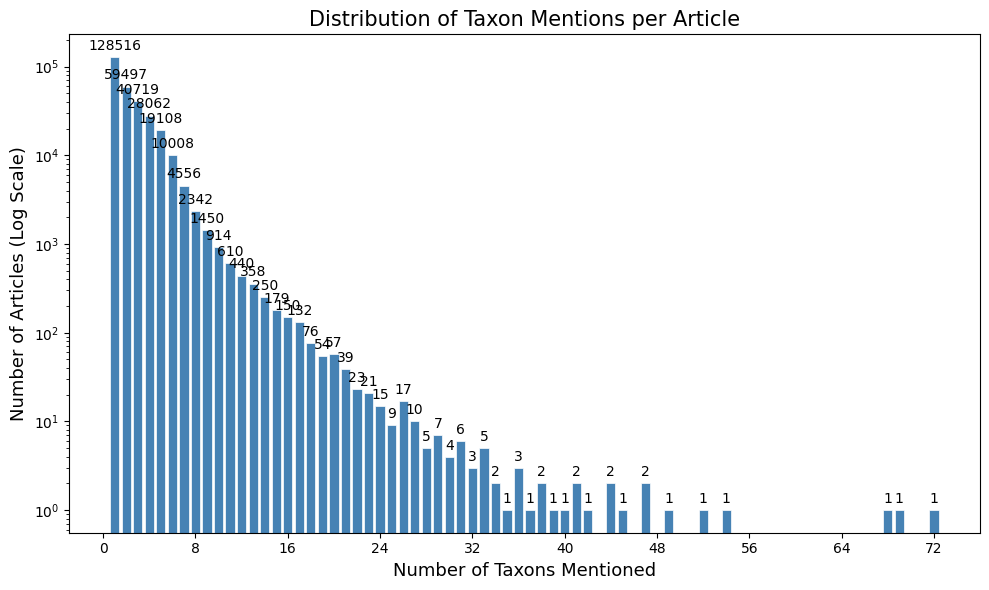

In [29]:
import matplotlib.pyplot as plt


def plot_per_article_taxons(taxon_hits: pd.DataFrame, title: str):
       # Group by article_id and count unique taxons per article
       taxons_per_article = taxon_hits.groupby('article_id')['taxon_id'].nunique()

       # Count how many articles have each number of taxons
       taxon_count_distribution = taxons_per_article.value_counts().sort_index()

       # Plot
       fig, ax = plt.subplots(figsize=(10, 6))
       bars = ax.bar(taxon_count_distribution.index, taxon_count_distribution.values, 
                     color='steelblue', edgecolor='white', linewidth=0.5)

       # --- NEW: Log-scale the Y-axis ---
       ax.set_yscale('log')
       # ---------------------------------

       # Add labels on top of bars (highly recommended for log scales!)
       ax.bar_label(bars, padding=3, fontsize=10)

       ax.set_xlabel('Number of Taxons Mentioned', fontsize=13)
       ax.set_ylabel('Number of Articles (Log Scale)', fontsize=13) # Updated label
       ax.set_title(title, fontsize=15)
       ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
       
       # CRITICAL: Remove the integer locator for y-axis if using log scale,
       # as matplotlib needs its own LogLocator to format the 10^0, 10^1 ticks properly.

       plt.tight_layout()
       plt.show()
plot_per_article_taxons(taxon_hits_filtered, 'Distribution of Taxon Mentions per Article')

In [9]:
# Filtering

# Remove any special characters that are not hyphens
mirna_hits["prefix"] = (
    mirna_hits["prefix"]
    .str.replace(r"[^a-zA-Z0-9-]", "", regex=True)
    .str.strip()
)

# Set everything to lower-case
mirna_hits['prefix'] = mirna_hits['prefix'].str.lower()

# Load valid prefixes and remove any prefix that does not have a valid prefix.
valid_prefixes = set(mirna_prefixes['prefix'] + '-')
is_valid_prefix = mirna_hits["prefix"].fillna("").isin(valid_prefixes)
mirna_hits.loc[~is_valid_prefix, "prefix"] = None


# Filter suffixes
suffix_pattern = r"((-|_|x| )?[0-9]+([a-g\*p]+)?(-[35]p)?[0-9]*)"
mirna_hits['matched_suffix'] = mirna_hits['suffix'].str.extract(suffix_pattern)[0]


In [88]:
# Matching family names
from emblUtils import parse_mirbase_embl
mirbase = parse_mirbase_embl('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/miRNA.dat')
mirbase['prefix'] = mirbase['name'].str.split('-').str[0]

mirbase.tail()

,name,accession,prefix
38584,smc-mir-12461,MI0041070,smc
38585,hsa-mir-9902-2,MI0041071,hsa
38586,gga-mir-1784b,MI0041072,gga
38587,mdo-mir-7385g-1,MI0041073,mdo
38588,mdo-mir-7385g-2,MI0041074,mdo


In [87]:
mirna_2_prefam = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mi_2_mipf.txt', sep='\t')
mirna_2_prefam['MI'] = mirna_2_prefam['MI'].str.replace('MI', 'MIPF')
mirna_2_prefam['MIPF'] = mirna_2_prefam['MIPF'].str.replace('MIPF', 'MI')

mirna_2_prefam.head()

,MI,MIPF
0,MIPF0064685,MI0007160
1,MIPF0064686,MI0007447
2,MIPF0064687,MI0007194
3,MIPF0064688,MI0007205
4,MIPF0064689,MI0007195


In [75]:
mirna_articles = mirna_hits.groupby('article_id', as_index=False).size()
taxons_articles = taxon_hits_filtered.groupby('article_id', as_index=False).size()
combined = pd.merge(mirna_articles, taxons_articles, on='article_id', how='inner')

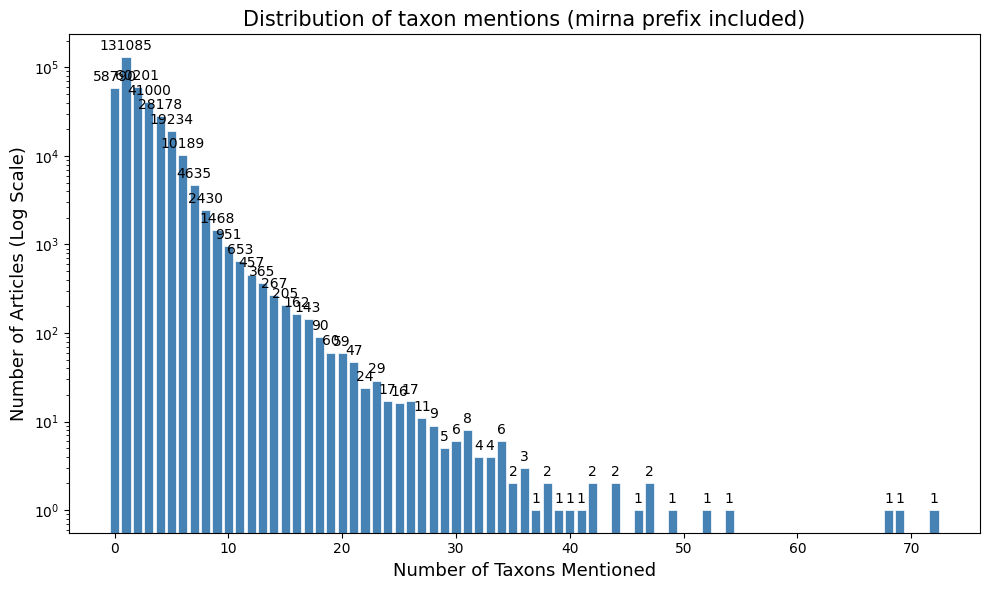

In [30]:
tax_id_to_prefix = dict(zip(mirna_prefixes['id'], mirna_prefixes['prefix'] + '-'))
prefix_to_tax_id = dict(zip(mirna_prefixes['prefix'] + '-', mirna_prefixes['id']))

mirna_hits['taxon_id'] = mirna_hits['prefix'].map(prefix_to_tax_id)
combined = pd.concat([mirna_hits[['article_id', 'taxon_id']], taxon_hits_filtered[['article_id', 'taxon_id']]], ignore_index=True)
plot_per_article_taxons(combined, 'Distribution of taxon mentions (mirna prefix included)')


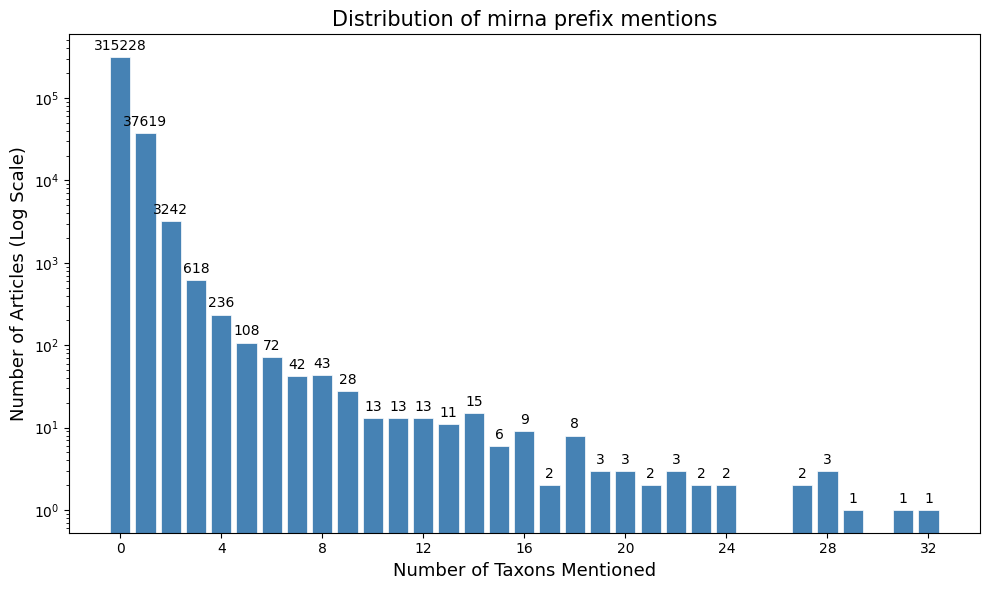

In [31]:
plot_per_article_taxons(mirna_hits, 'Distribution of mirna prefix mentions')

In [11]:
joined = pd.merge(mirna_hits[['sentence_id', 'synonym', 'prefix', 'suffix', 'article_id']], taxon_hits_filtered[['sentence_id', 'matched_text', 'taxon_id']], how='outer', on='sentence_id')

In [29]:
tax_id_to_prefix = dict(zip(mirna_prefixes['id'], mirna_prefixes['prefix'] + '-'))
prefix_to_tax_id = dict(zip(mirna_prefixes['prefix'] + '-', mirna_prefixes['id']))

joined['implied_prefix'] = joined['taxon_id'].map(tax_id_to_prefix)
joined['implied_taxon'] = joined['prefix'].map(prefix_to_tax_id)

joined.head()

,sentence_id,synonym,prefix,suffix,article_id,matched_text,taxon_id,implied_prefix,implied_taxon
0,10028644.1.1,lsy,NaN,4.,10028644,NaN,NaN,NaN,NaN
1,10028644.2.1,lsy,NaN,4,10028644,NaN,NaN,NaN,NaN
2,10028644.2.6,lsy,NaN,4,10028644,NaN,NaN,NaN,NaN
3,10066355.2.3,miR,NaN,-95,10066355,NaN,NaN,NaN,NaN
4,10177113.2.6,bantam,NaN,"Books,",10177113,Bantam,NCBITaxon_9031,gga-,NaN


In [65]:
mirna_articles = mirna_hits.groupby('article_id', as_index=False).size()
taxons_articles = taxon_hits_filtered.groupby('article_id', as_index=False).size()

combined = pd.merge(mirna_articles, taxons_articles, on='article_id', how='left')
out = combined['size_y'].notna().sum()

print(f'Mirna articles: {len(mirna_articles)}')
print(f'Mirna articles with taxon mention: {out}')

combined.head(15)

Mirna articles: 357349
Mirna articles with taxon mention: 143974


,article_id,size_x,size_y
0,10028644,3,NaN
1,10066355,1,NaN
2,10177113,1,1.0
3,10188023,1,NaN
4,10355369,1,2.0
5,10364429,9,NaN
6,10375498,3,NaN
7,10390237,3,NaN
8,10394950,11,5.0
9,10404045,1,NaN


In [130]:
precursors = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/precursors.tsv', sep='\t')
fam = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/mirna_prefam.txt', sep='\t')
pre_2_fam = pd.read_csv('/mnt/raidbio2/extproj/projekte/textmining/mirnaTextmining/mirClassification/data/mirbase/mipf_2_mi.tsv', sep='\t')

mirna_hits.head(30)

,sentence_id,synonym_id,matched_text,start_position,hit_length,synonym,prefix,suffix,article_id,matched_suffix,taxon_id
0,PMC12100665.2.11,0:0,miR,4,3,miR,ath-,397,PMC12100665,397,NCBITaxon_3702
1,PMC12100665.3.45,0:0,miR,4,3,miR,NaN,397,PMC12100665,397,NaN
2,PMC12100665.5.100,0:0,miR,125,3,miR,NaN,397,PMC12100665,397,NaN
3,PMC12100665.5.101,0:0,miR,18,3,miR,ath-,397a,PMC12100665,397a,NCBITaxon_3702
4,PMC12100665.5.102,0:0,miR,19,3,miR,ath-,397b,PMC12100665,397b,NCBITaxon_3702
5,PMC12100665.5.103,0:0,miR,160,3,miR,ath-,397b.,PMC12100665,397b,NCBITaxon_3702
6,PMC12100665.5.103,0:0,miR,144,3,miR,ath-,397a,PMC12100665,397a,NCBITaxon_3702
7,PMC12100665.5.104,0:0,miR,24,3,miR,NaN,397,PMC12100665,397,NaN
8,PMC12100665.5.105,0:0,miR,29,3,miR,NaN,397,PMC12100665,397,NaN
9,PMC12100665.5.105,0:0,miR,57,3,miR,ath-,397b),PMC12100665,397b,NCBITaxon_3702
